# LIGO - Gravitational Waves Detectability

**Today's task is to train a classifier (you decide which one!) and separate sources that are detectables from those that aren't.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
sys.path.append(r"C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks")
from Utilities import plot_settings

Load downsampled data with balanced classes members

In [2]:
y = np.load(r"C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks\Exam\LIGO\LIGO_v2\Npy\y.npy")

In [3]:
data = np.load(r"C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks\Exam\LIGO\LIGO_v2\Npy\data.npy")

In [4]:
keys = np.load(r"C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks\Exam\LIGO\LIGO_v2\Npy\keys.npy")

In [5]:
df = pd.DataFrame(data, columns=keys)

In [6]:
df = df.drop(columns=['snr', 'det'])

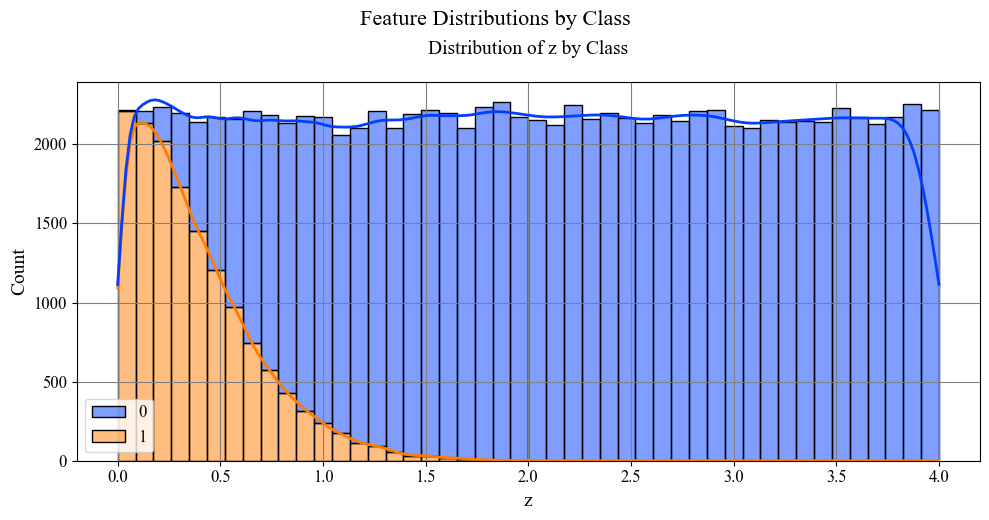

In [7]:
col = 12
sns.histplot(data=df, x=df.columns[col], hue=y, multiple='stack', bins='scott', kde=True, palette='bright')
plt.title(f'Distribution of {df.columns[col]} by Class', fontsize=14)
plt.xlabel(df.columns[col])
plt.ylabel('Count')

plt.tight_layout()
plt.suptitle('Feature Distributions by Class', fontsize=16, y=1.03);

None of the features seems to exhibit an apparent classification boundary.\
Let's try to see what PCA tells me about explained variance ratio.

In [8]:
X = df.to_numpy()

In [9]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

In [10]:
Scaler = RobustScaler()
X_scaled = Scaler.fit_transform(X)

In [11]:
pca = PCA(n_components=int(X.shape[1]))
X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'Explained variance ratio')

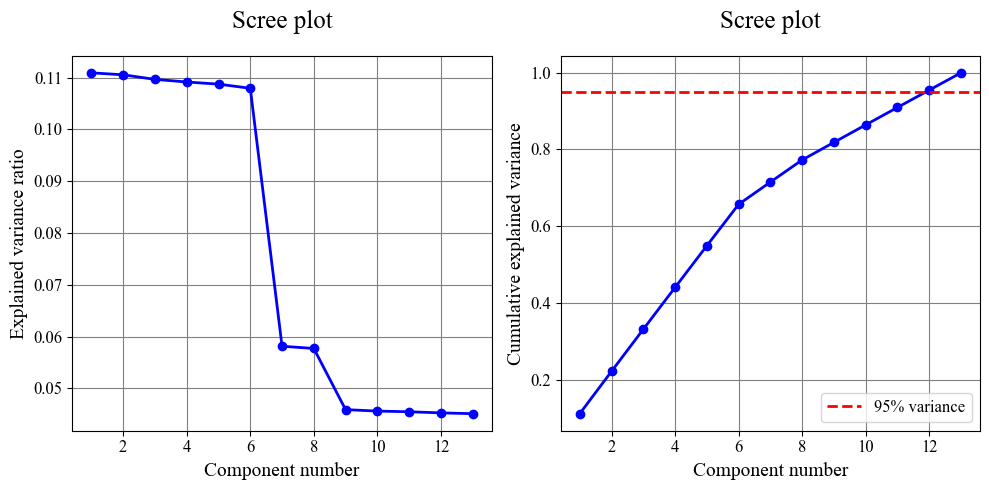

In [12]:
fig, axs = plt.subplots(1, 2)
axs[1].plot(range(1,pca.n_components+1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='-', color='blue')
axs[1].set_title('Scree plot')
axs[1].set_xlabel('Component number')
axs[1].axhline(0.95, 0, 1, linestyle='--', color='red', label='95% variance')
axs[1].set_ylabel('Cumulative explained variance')
axs[1].legend()

axs[0].plot(range(1,pca.n_components+1), pca.explained_variance_ratio_, marker='o', linestyle='-', color='blue')
axs[0].set_title('Scree plot')
axs[0].set_xlabel('Component number')
axs[0].set_ylabel('Explained variance ratio')

Looking at the scree plot, to explain $95 \%$ of the variance I'd need at least 12 over 13 features...not encouraging.\
Maybe the relationships between features are non linear. Let's see what LLE has to say about this.

In [16]:
from sklearn.manifold import LocallyLinearEmbedding

In [ ]:
LLE = LocallyLinearEmbedding(n_components=2, n_neighbors=20)
X_lle = LLE.fit_transform(X_scaled)